In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.optimize import linprog

try:
    from IPython.display import display
except ImportError:
    display = print


@dataclass
class SPDSystem:
    A: np.ndarray
    b: np.ndarray
    x_star: np.ndarray
    ell0: np.ndarray
    u0: np.ndarray

    @property
    def n(self):
        return self.A.shape[0]


def generate_spd_system(
    n,
    box_scale=1.0,
    condition_number=25.0,
    seed=None,
):
    """
    Generate a nontrivial SPD linear system Ax=b with known solution x_star,
    together with a non-centered, unequal-side hyperbox guaranteed to contain x_star.
    """
    rng = np.random.default_rng(seed)

    # Random orthogonal matrix
    M = rng.normal(size=(n, n))
    Q, _ = np.linalg.qr(M)

    # Spread eigenvalues to make A nontrivial but well controlled
    eigs = np.geomspace(1.0, condition_number, n)
    rng.shuffle(eigs)

    A = Q @ np.diag(eigs) @ Q.T
    A = 0.5 * (A + A.T)  # numerical symmetry cleanup

    # Exact solution and right-hand side
    x_star = rng.normal(loc=0.0, scale=2.0, size=n)
    b = A @ x_star

    # Unequal and non-centered margins around the solution
    base = box_scale * (0.5 + rng.random(n)) * (1.0 + np.abs(x_star))
    left_margin = base * (0.4 + rng.random(n))
    right_margin = base * (0.4 + rng.random(n))

    # Avoid accidental symmetry in any coordinate
    near_equal = np.isclose(left_margin, right_margin)
    right_margin[near_equal] *= 1.25

    ell0 = x_star - left_margin
    u0 = x_star + right_margin

    return SPDSystem(A=A, b=b, x_star=x_star, ell0=ell0, u0=u0)

In [2]:
@dataclass
class ICGResult:
    ell: np.ndarray
    u: np.ndarray
    x_cg: np.ndarray
    residual: np.ndarray
    n_iters: int
    history: list | None


def _coordinate_bounds_from_constraints(A, b, ell0, u0, directions):
    """
    Compute coordinate-wise min/max over

        B0 ∩ {x : p_j^T A x = p_j^T b, j = 0, ..., k}

    using linear programming.
    """
    n = A.shape[0]

    A_eq = np.vstack([p @ A for p in directions])
    b_eq = np.array([p @ b for p in directions])

    # Normalize equality rows for better numerical stability
    row_norms = np.linalg.norm(A_eq, axis=1)
    nonzero = row_norms > 0
    A_eq = A_eq[nonzero] / row_norms[nonzero, None]
    b_eq = b_eq[nonzero] / row_norms[nonzero]

    bounds = list(zip(ell0, u0))

    ell = np.empty(n)
    u = np.empty(n)

    for i in range(n):
        c = np.zeros(n)
        c[i] = 1.0

        min_res = linprog(
            c,
            A_eq=A_eq,
            b_eq=b_eq,
            bounds=bounds,
            method="highs",
        )

        if not min_res.success:
            raise RuntimeError(f"LP minimization failed for coordinate {i}: {min_res.message}")

        max_res = linprog(
            -c,
            A_eq=A_eq,
            b_eq=b_eq,
            bounds=bounds,
            method="highs",
        )

        if not max_res.success:
            raise RuntimeError(f"LP maximization failed for coordinate {i}: {max_res.message}")

        ell[i] = min_res.fun
        u[i] = -max_res.fun

    return ell, u


def interval_conjugate_gradient(
    system,
    ell0=None,
    u0=None,
    m=None,
    verbose=True,
    tol=1e-10,
):
    """
    Implements the Interval Conjugate Gradient algorithm.

    Parameters
    ----------
    system:
        SPDSystem object.
    ell0, u0:
        Optional initial hyperbox. If omitted, uses system.ell0 and system.u0.
    m:
        Number of iterations. If None, runs up to n CG iterations or convergence.
    verbose:
        If True, stores the full iteration history.
        If False, returns only the final hyperbox and final CG point.
    tol:
        Numerical convergence tolerance for the CG residual.
    """
    A = system.A
    b = system.b
    n = system.n

    ell0 = np.array(system.ell0 if ell0 is None else ell0, dtype=float)
    u0 = np.array(system.u0 if u0 is None else u0, dtype=float)

    if m is None:
        max_iter = n
    else:
        max_iter = int(m)
        if max_iter < 0 or max_iter > n:
            raise ValueError("m must satisfy 0 <= m <= n.")

    x = 0.5 * (ell0 + u0)
    r = b - A @ x
    p = r.copy()

    ell_current = ell0.copy()
    u_current = u0.copy()

    directions = []

    history = [] if verbose else None

    if verbose:
        history.append(
            {
                "iteration": 0,
                "ell": ell_current.copy(),
                "u": u_current.copy(),
                "x": x.copy(),
                "r": r.copy(),
                "p": p.copy(),
                "alpha": None,
                "beta": None,
                "x_before": None,
                "r_before": None,
                "p_used": None,
            }
        )

    iters_done = 0

    for k in range(max_iter):
        if np.linalg.norm(r) <= tol:
            break

        # Add current CG direction p_k to the accumulated interval constraints
        directions.append(p.copy())

        # Interval update: use B0, not the previous hyperbox, as in the stated algorithm
        ell_current, u_current = _coordinate_bounds_from_constraints(
            A=A,
            b=b,
            ell0=ell0,
            u0=u0,
            directions=directions,
        )

        # Usual CG update
        Ap = A @ p
        denom = p @ Ap

        if abs(denom) <= tol:
            break

        alpha = (r @ r) / denom

        x_next = x + alpha * p
        r_next = r - alpha * Ap

        if r @ r <= tol:
            beta = 0.0
        else:
            beta = (r_next @ r_next) / (r @ r)

        p_next = r_next + beta * p

        iters_done = k + 1

        if verbose:
            history.append(
                {
                    "iteration": k + 1,
                    "ell": ell_current.copy(),
                    "u": u_current.copy(),
                    "x": x_next.copy(),
                    "r": r_next.copy(),
                    "p": p_next.copy(),
                    "alpha": alpha,
                    "beta": beta,
                    "x_before": x.copy(),
                    "r_before": r.copy(),
                    "p_used": p.copy(),
                }
            )

        x, r, p = x_next, r_next, p_next

        if np.linalg.norm(r) <= tol:
            break

    return ICGResult(
        ell=ell_current,
        u=u_current,
        x_cg=x,
        residual=r,
        n_iters=iters_done,
        history=history,
    )

In [25]:
from matplotlib.patches import Rectangle


def _add_rectangle(ax, ell, u, label, linewidth=1.0, alpha=0.15):
    width = u[0] - ell[0]
    height = u[1] - ell[1]

    rect = Rectangle(
        (ell[0], ell[1]),
        width,
        height,
        fill=True,
        alpha=alpha,
        linewidth=linewidth,
        edgecolor="black",
        label=label,
    )
    ax.add_patch(rect)


def _line_segment_in_box(c, d, ell, u, tol=1e-10):
    """
    Find the segment of the line

        c[0] x[0] + c[1] x[1] = d

    lying inside the 2D box [ell, u].
    """
    points = []

    # Intersections with vertical sides: x1 = ell[0], u[0]
    if abs(c[1]) > tol:
        for x_val in [ell[0], u[0]]:
            y_val = (d - c[0] * x_val) / c[1]
            if ell[1] - tol <= y_val <= u[1] + tol:
                points.append(np.array([x_val, y_val]))

    # Intersections with horizontal sides: x2 = ell[1], u[1]
    if abs(c[0]) > tol:
        for y_val in [ell[1], u[1]]:
            x_val = (d - c[1] * y_val) / c[0]
            if ell[0] - tol <= x_val <= u[0] + tol:
                points.append(np.array([x_val, y_val]))

    # Remove duplicate corner intersections
    unique_points = []
    for p in points:
        if not any(np.linalg.norm(p - q) < tol for q in unique_points):
            unique_points.append(p)

    if len(unique_points) < 2:
        raise ValueError("The line does not cut the hyperbox in a visible segment.")

    # If numerical issues produce more than two points, keep the farthest pair
    max_dist = -np.inf
    segment = None

    for i in range(len(unique_points)):
        for j in range(i + 1, len(unique_points)):
            dist = np.linalg.norm(unique_points[i] - unique_points[j])
            if dist > max_dist:
                max_dist = dist
                segment = (unique_points[i], unique_points[j])

    return segment


def plot_icg_2d(system, result):
    """
    For a 2D verbose ICG result, plot only:
    - the initial shaded hyperbox B0,
    - the updated shaded hyperbox B1,
    - the line segment p0^T A x = p0^T b constrained to B0,
    - x0,
    - x1,
    - x2 = x_star.
    """
    if system.n != 2:
        raise ValueError("This plot is only defined for n=2.")

    if result.history is None:
        raise ValueError("Run interval_conjugate_gradient(..., verbose=True) first.")

    if len(result.history) < 2:
        raise ValueError("Need at least one CG iteration to plot.")

    h0 = result.history[0]
    h1 = result.history[1]

    x0 = h0["x"]
    p0 = h0["p"]
    x1 = h1["x"]
    x_star = system.x_star

    fig, ax = plt.subplots(figsize=(8, 8))

    # Shaded boxes with thinner boundaries
    _add_rectangle(
        ax,
        h0["ell"],
        h0["u"],
        label=r"Initial hyperbox $B_0$",
        linewidth=1.0,
        alpha=0.12,
    )

    _add_rectangle(
        ax,
        h1["ell"],
        h1["u"],
        label=r"Updated hyperbox $B_1$",
        linewidth=1.0,
        alpha=0.22,
    )

    # Constraint line:
    # p0^T A x = p0^T b
    c = p0 @ system.A
    d = p0 @ system.b

    z0, z1 = _line_segment_in_box(c, d, h0["ell"], h0["u"])

    ax.plot(
        [z0[0], z1[0]],
        [z0[1], z1[1]],
        linewidth=2,
        label=r"$p_0^T A x = p_0^T b$ in $B_0$",
    )

    # Points
    ax.scatter(x0[0], x0[1], s=70, label=r"$x_0$")
    ax.scatter(x1[0], x1[1], s=70, label=r"$x_1$")
    ax.scatter(
        x_star[0],
        x_star[1],
        s=120,
        marker="*",
        label=r"$x_2=x_\star$",
    )

    # Optional point labels
    ax.text(x0[0], x0[1], r"  $x_0$", va="center")
    ax.text(x1[0], x1[1], r"  $x_1$", va="center")
    ax.text(x_star[0], x_star[1], r"  $x_2 = x_*$", va="center")

    all_points = np.vstack(
        [
            h0["ell"],
            h0["u"],
            h1["ell"],
            h1["u"],
            z0,
            z1,
            x0,
            x1,
            x_star,
        ]
    )

    mins = all_points.min(axis=0)
    maxs = all_points.max(axis=0)
    padding = 0.15 * np.maximum(maxs - mins, 1.0)

    ax.set_xlim(mins[0] - padding[0], maxs[0] + padding[0])
    ax.set_ylim(mins[1] - padding[1], maxs[1] + padding[1])

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"Constraint $p_0^T A x = p_0^T b$ Inside the Hyperbox")
    ax.grid(True)
    ax.legend()
    ax.set_aspect("equal", adjustable="box")

    plt.show()

A =
[[ 9.38554572 -2.26991948]
 [-2.26991948  1.61445428]]

b =
[16.08243216 -6.07926906]

Exact solution x_star =
[ 1.21649002 -2.05514316]

Initial lower bounds ell0 =
[-2.39740975 -6.26586197]

Initial upper bounds u0 =
[3.91597606 5.94924043]

Final interval lower bounds =
[ 1.21649002 -2.05514316]

Final interval upper bounds =
[ 1.21649002 -2.05514316]

Final CG iterate =
[ 1.21649002 -2.05514316]

Residual norm =
7.0014505417448634e-15


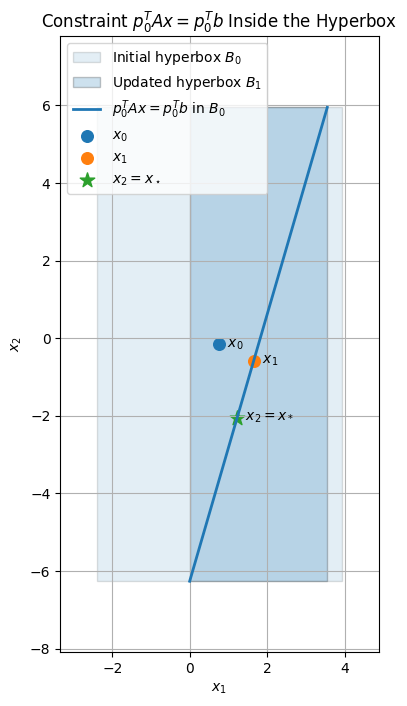

In [27]:
system2 = generate_spd_system(
    n=2,
    box_scale=2,
    condition_number=10.0,
    seed=124,
)

result2 = interval_conjugate_gradient(
    system2,
    m=None,
    verbose=True,
)

print("A =")
print(system2.A)

print("\nb =")
print(system2.b)

print("\nExact solution x_star =")
print(system2.x_star)

print("\nInitial lower bounds ell0 =")
print(system2.ell0)

print("\nInitial upper bounds u0 =")
print(system2.u0)

print("\nFinal interval lower bounds =")
print(result2.ell)

print("\nFinal interval upper bounds =")
print(result2.u)

print("\nFinal CG iterate =")
print(result2.x_cg)

print("\nResidual norm =")
print(np.linalg.norm(result2.residual))

plot_icg_2d(system2, result2)

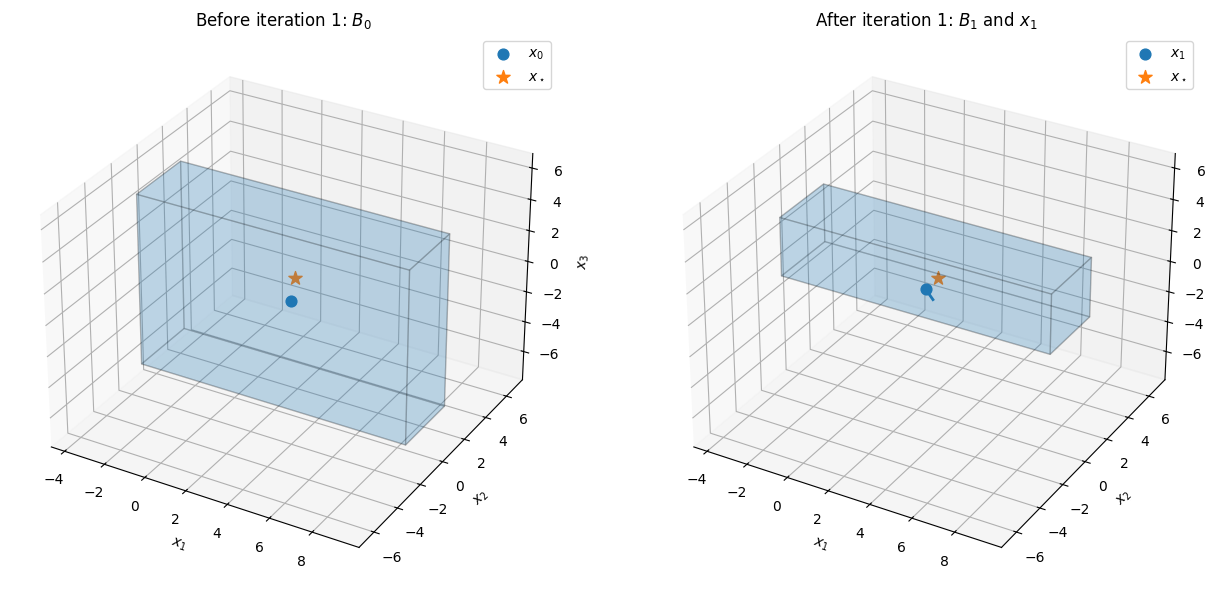

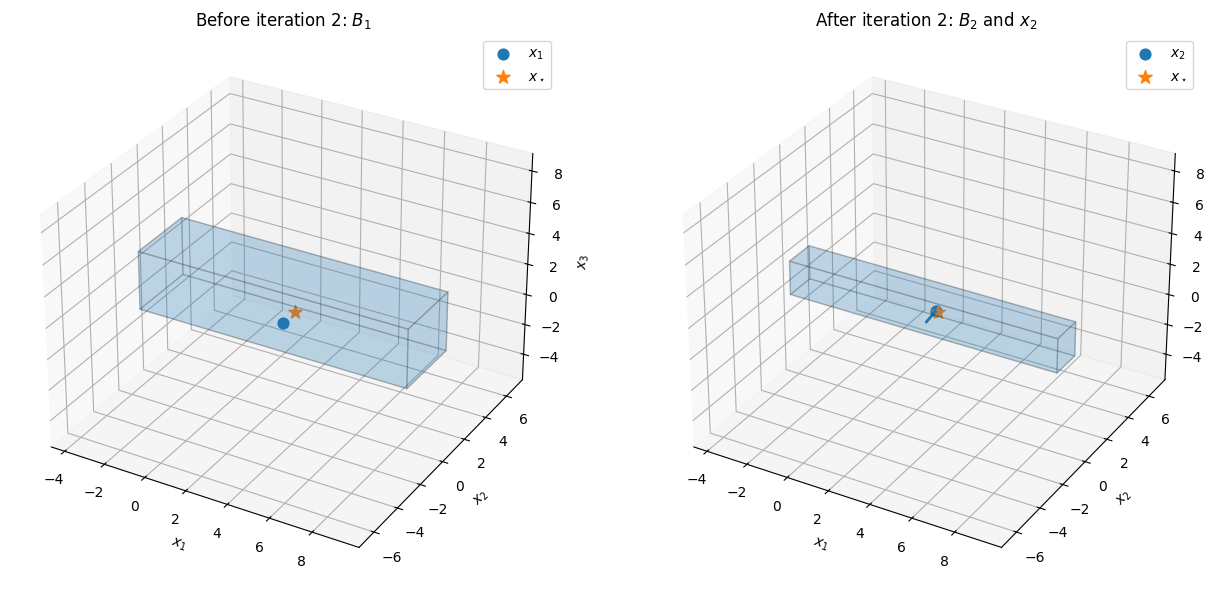

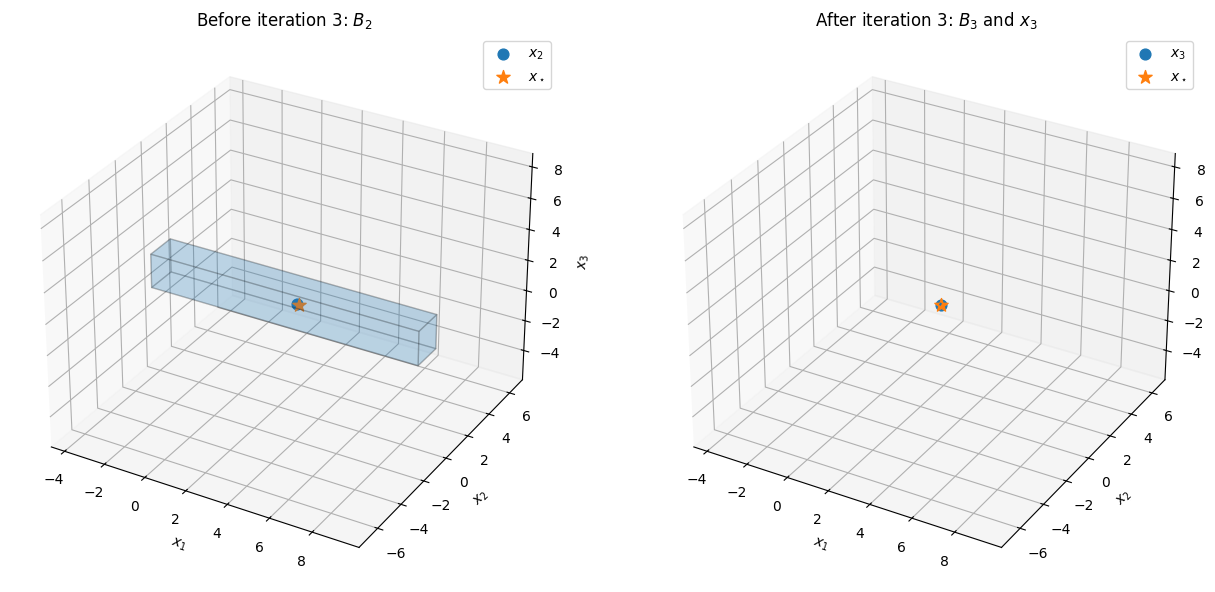

In [11]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def _box_faces_3d(ell, u):
    x0, y0, z0 = ell
    x1, y1, z1 = u

    vertices = np.array(
        [
            [x0, y0, z0],
            [x1, y0, z0],
            [x1, y1, z0],
            [x0, y1, z0],
            [x0, y0, z1],
            [x1, y0, z1],
            [x1, y1, z1],
            [x0, y1, z1],
        ]
    )

    faces = [
        [vertices[i] for i in [0, 1, 2, 3]],
        [vertices[i] for i in [4, 5, 6, 7]],
        [vertices[i] for i in [0, 1, 5, 4]],
        [vertices[i] for i in [2, 3, 7, 6]],
        [vertices[i] for i in [1, 2, 6, 5]],
        [vertices[i] for i in [0, 3, 7, 4]],
    ]

    return faces


def _draw_box_3d(ax, ell, u, alpha=0.12):
    faces = _box_faces_3d(ell, u)
    poly = Poly3DCollection(faces, alpha=alpha, linewidths=1)
    poly.set_edgecolor("black")
    ax.add_collection3d(poly)


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    center = 0.5 * (mins + maxs)
    radius = 0.55 * np.max(maxs - mins)

    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def plot_icg_3d_by_iteration(system, result):
    """
    For each iteration, make two 3D plots:
    left: hyperbox before the iteration,
    right: hyperbox after the interval update and CG step.
    """
    if system.n != 3:
        raise ValueError("This plot is only defined for n=3.")

    if result.history is None:
        raise ValueError("Run interval_conjugate_gradient(..., verbose=True) first.")

    hist = result.history

    for idx in range(1, len(hist)):
        before = hist[idx - 1]
        after = hist[idx]

        fig = plt.figure(figsize=(13, 6))

        ax1 = fig.add_subplot(1, 2, 1, projection="3d")
        ax2 = fig.add_subplot(1, 2, 2, projection="3d")

        _draw_box_3d(ax1, before["ell"], before["u"], alpha=0.15)
        ax1.scatter(*before["x"], s=60, label=fr"$x_{idx-1}$")
        ax1.scatter(*system.x_star, s=100, marker="*", label=r"$x_\star$")
        ax1.set_title(fr"Before iteration {idx}: $B_{idx-1}$")
        ax1.legend()

        _draw_box_3d(ax2, after["ell"], after["u"], alpha=0.15)
        ax2.scatter(*after["x"], s=60, label=fr"$x_{idx}$")
        ax2.scatter(*system.x_star, s=100, marker="*", label=r"$x_\star$")

        step = after["x"] - before["x"]
        ax2.quiver(
            before["x"][0],
            before["x"][1],
            before["x"][2],
            step[0],
            step[1],
            step[2],
            arrow_length_ratio=0.12,
            linewidth=2,
        )

        ax2.set_title(fr"After iteration {idx}: $B_{idx}$ and $x_{idx}$")
        ax2.legend()

        points = np.vstack(
            [
                before["ell"],
                before["u"],
                after["ell"],
                after["u"],
                before["x"],
                after["x"],
                system.x_star,
            ]
        )

        _set_equal_3d_axes(ax1, points)
        _set_equal_3d_axes(ax2, points)

        for ax in [ax1, ax2]:
            ax.set_xlabel(r"$x_1$")
            ax.set_ylabel(r"$x_2$")
            ax.set_zlabel(r"$x_3$")

        plt.tight_layout()
        plt.show()


system3 = generate_spd_system(
    n=3,
    box_scale=2.0,
    condition_number=15.0,
    seed=11,
)

result3 = interval_conjugate_gradient(
    system3,
    m=None,
    verbose=True,
)

plot_icg_3d_by_iteration(system3, result3)

In [12]:
def check_icg_history(system, result, tol=1e-8, verbose=True):
    """
    Checks, at every stored iteration k:

    1. Whether the true solution x_star is inside B_k.
    2. Whether the CG iterate x_k is inside B_k.
    3. Whether the interval has become degenerate.
    4. When each coordinate first becomes degenerate.

    Note: x_k can leave the Cartesian hyperbox even though x_star remains inside it.
    """
    if result.history is None:
        raise ValueError("This check requires a verbose solver result.")

    rows = []

    for state in result.history:
        k = state["iteration"]
        ell = state["ell"]
        u = state["u"]
        xk = state["x"]
        widths = u - ell

        x_star_inside = np.all(system.x_star >= ell - tol) and np.all(system.x_star <= u + tol)
        xk_inside = np.all(xk >= ell - tol) and np.all(xk <= u + tol)

        row = {
            "iteration": k,
            "x_star_inside_box": x_star_inside,
            "x_k_inside_box": xk_inside,
            "min_width": np.min(widths),
            "max_width": np.max(widths),
            "degenerate_dimensions": int(np.sum(widths <= tol)),
            "fully_degenerate": bool(np.all(widths <= tol)),
            "residual_norm": np.linalg.norm(state["r"]),
        }

        if verbose and system.n <= 15:
            for i in range(system.n):
                row[f"width_{i+1}"] = widths[i]

        rows.append(row)

    df = pd.DataFrame(rows)

    if df["fully_degenerate"].any():
        first_fully_degenerate = int(df.loc[df["fully_degenerate"], "iteration"].iloc[0])
    else:
        first_fully_degenerate = None

    first_degenerate_by_coordinate = {}

    for i in range(system.n):
        first = None
        for state in result.history:
            width_i = state["u"][i] - state["ell"][i]
            if width_i <= tol:
                first = int(state["iteration"])
                break

        first_degenerate_by_coordinate[f"x_{i+1}"] = first

    summary = {
        "all_x_star_checks_passed": bool(df["x_star_inside_box"].all()),
        "all_x_k_checks_passed": bool(df["x_k_inside_box"].all()),
        "first_fully_degenerate_iteration": first_fully_degenerate,
        "first_degenerate_by_coordinate": first_degenerate_by_coordinate,
        "final_max_width": float(df["max_width"].iloc[-1]),
        "final_residual_norm": float(df["residual_norm"].iloc[-1]),
    }

    if verbose:
        display(df)
        print("Summary:")
        print(summary)

    return df, summary

In [13]:
check2_df, check2_summary = check_icg_history(
    system2,
    result2,
    tol=1e-8,
    verbose=True,
)

# A somewhat higher-dimensional test without printing the full coordinate-wise table
system_high = generate_spd_system(
    n=12,
    box_scale=2.0,
    condition_number=30.0,
    seed=21,
)

result_high = interval_conjugate_gradient(
    system_high,
    m=None,
    verbose=True,
)

check_high_df, check_high_summary = check_icg_history(
    system_high,
    result_high,
    tol=1e-8,
    verbose=False,
)

check_high_summary

,iteration,x_star_inside_box,x_k_inside_box,min_width,max_width,degenerate_dimensions,fully_degenerate,residual_norm,width_1,width_2
0,0,True,True,4.617812,5.422174,0,False,1.122437e+00,4.617812,5.422174
1,1,True,True,3.858431,4.617812,0,False,3.175699e-01,4.617812,3.858431
2,2,True,True,0.000000,0.000000,2,True,1.205052e-15,0.000000,0.000000


Summary:
{'all_x_star_checks_passed': True, 'all_x_k_checks_passed': True, 'first_fully_degenerate_iteration': 2, 'first_degenerate_by_coordinate': {'x_1': 2, 'x_2': 2}, 'final_max_width': 0.0, 'final_residual_norm': 1.2050523549074438e-15}


{'all_x_star_checks_passed': True,
 'all_x_k_checks_passed': True,
 'first_fully_degenerate_iteration': 12,
 'first_degenerate_by_coordinate': {'x_1': 12,
  'x_2': 12,
  'x_3': 12,
  'x_4': 12,
  'x_5': 12,
  'x_6': 12,
  'x_7': 12,
  'x_8': 12,
  'x_9': 12,
  'x_10': 12,
  'x_11': 12,
  'x_12': 12},
 'final_max_width': 1.3322676295501878e-15,
 'final_residual_norm': 5.41628085930747e-09}